# Análise Geoespacial do PIB — Municípios do Ceará

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Carregamento e validação da malha municipal

Total de municípios: 184
Geometrias inválidas antes: 5
Geometrias inválidas depois: 0


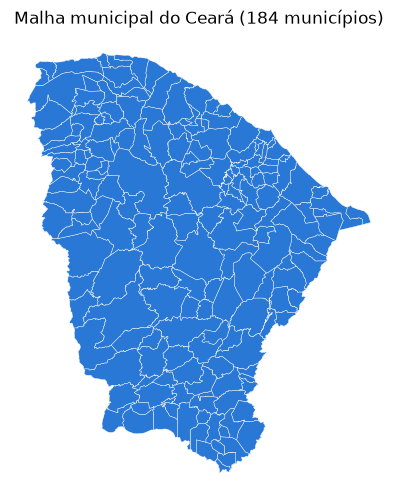

In [ ]:
gdf_municipios = gpd.read_file("../dados/raw/malha_municipal_ce_2022.geojson")

print(f"Total de municípios: {gdf_municipios.shape[0]}")
print(f"Geometrias inválidas antes: {(~gdf_municipios.geometry.is_valid).sum()}")

gdf_municipios["geometry"] = gdf_municipios["geometry"].make_valid()

print(f"Geometrias inválidas depois: {(~gdf_municipios.geometry.is_valid).sum()}")

gdf_municipios.plot(figsize=(6, 6), color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.3)
plt.title("Malha municipal do Ceará (184 municípios)")
plt.axis("off")
plt.show()

## Carregamento do PIB por município

In [ ]:
df_pib_raw = pd.read_csv("../dados/processed/pib_tratado.csv")

pib_municipios_geo = df_pib_raw[
    (df_pib_raw["nivel_territorial_nome"] == "Município")
    & (df_pib_raw["variavel_nome"] == "Produto Interno Bruto a preços correntes")
].copy()
pib_municipios_geo["territorio_codigo"] = pib_municipios_geo["territorio_codigo"].astype(str)

pib_municipios_geo_pivot = pib_municipios_geo.pivot(index="ano_nome", columns="territorio_codigo", values="valor")

print(f"Municípios com PIB: {pib_municipios_geo_pivot.shape[1]}")
pib_municipios_geo_pivot.head()

Municípios com PIB: 184


territorio_codigo,2300101,2300150,2300200,2300309,2300408,2300507,2300606,2300705,2300754,2300804,...,2313500,2313559,2313609,2313708,2313757,2313807,2313906,2313955,2314003,2314102
ano_nome,,,,,,,,,,,,,,,,,,,,,
2003,17657.0,32448.0,124068.0,94074.0,23473.0,17349.0,10409.0,35944.0,117176.0,13430.0,...,126907.0,18205.0,84184.0,12548.0,27645.0,60859.0,18129.0,44897.0,73459.0,86705.0
2004,16808.0,33397.0,146593.0,101418.0,23256.0,17539.0,11469.0,38299.0,130447.0,14399.0,...,161362.0,21272.0,98534.0,12972.0,30821.0,107867.0,19739.0,46444.0,68252.0,99491.0
2005,17153.0,33577.0,151979.0,103497.0,29550.0,21533.0,12431.0,40261.0,154484.0,16694.0,...,177958.0,24710.0,110140.0,14272.0,33672.0,106364.0,23361.0,47935.0,76721.0,105981.0
2006,22869.0,36982.0,171739.0,123962.0,37163.0,22937.0,15410.0,45855.0,165374.0,21001.0,...,210910.0,27427.0,124395.0,18952.0,37992.0,112011.0,24745.0,60202.0,95373.0,136367.0
2007,25383.0,42765.0,190070.0,127767.0,38449.0,26489.0,17005.0,55847.0,151945.0,20701.0,...,213388.0,28736.0,142290.0,18629.0,42991.0,108840.0,29731.0,60949.0,98960.0,152980.0


## Junção geometria + PIB

In [ ]:
gdf_pib = gdf_municipios.merge(
    pib_municipios_geo_pivot.T,
    left_on="codarea",
    right_index=True,
    how="left",
)

nomes_municipios = (
    pib_municipios_geo.drop_duplicates("territorio_codigo")
    .set_index("territorio_codigo")["territorio_nome"]
)
gdf_pib.insert(1, "nome", gdf_pib["codarea"].map(nomes_municipios))

nao_casaram = gdf_pib[gdf_pib[2023].isna()]
print(f"Municípios sem PIB casado: {len(nao_casaram)}")
gdf_pib.head()

Municípios sem PIB casado: 0


,codarea,nome,geometry,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,2300101,Abaiara - CE,"POLYGON ((-39.0782 -7.422, -39.03 -7.4244, -38...",17657.0,16808.0,17153.0,22869.0,25383.0,30985.0,34757.0,...,64718.0,66037.0,73672.0,92951.0,87933.0,94460.0,108505.0,117971.0,126794.0,143730.0
1,2300150,Acarape - CE,"POLYGON ((-38.6869 -4.2871, -38.6825 -4.287, -...",32448.0,33397.0,33577.0,36982.0,42765.0,50859.0,56351.0,...,114161.0,118734.0,127927.0,150071.0,125559.0,142409.0,155396.0,179994.0,183507.0,220474.0
2,2300200,Acaraú - CE,"MULTIPOLYGON (((-40.3663 -2.8111, -40.3612 -2....",124068.0,146593.0,151979.0,171739.0,190070.0,225541.0,239320.0,...,523629.0,551031.0,581919.0,634060.0,567089.0,708010.0,838948.0,1020201.0,1184672.0,1250251.0
3,2300309,Acopiara - CE,"POLYGON ((-39.3633 -5.9809, -39.3658 -5.9798, ...",94074.0,101418.0,103497.0,123962.0,127767.0,160679.0,170027.0,...,334997.0,348629.0,376458.0,396748.0,389055.0,462562.0,515638.0,564520.0,604192.0,693535.0
4,2300408,Aiuaba - CE,"POLYGON ((-40.3705 -6.8032, -40.364 -6.8068, -...",23473.0,23256.0,29550.0,37163.0,38449.0,50232.0,48215.0,...,93440.0,106085.0,101735.0,104668.0,112897.0,129382.0,151775.0,151596.0,146744.0,169076.0


Qual o PIB de cada município do Ceará, no mapa, em 2023?

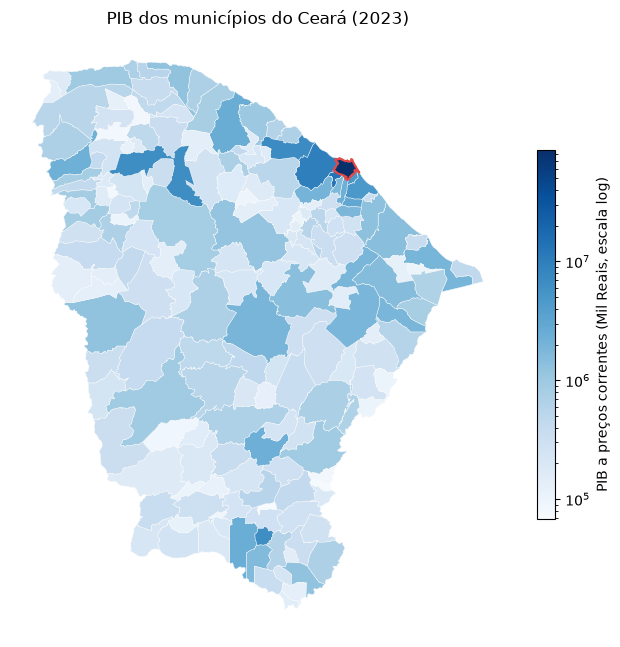

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_pib.plot(
    column=2023,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_pib[2023].min(), vmax=gdf_pib[2023].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "PIB a preços correntes (Mil Reais, escala log)", "shrink": 0.6},
    ax=ax,
)

fortaleza = gdf_pib[gdf_pib["codarea"] == "2304400"]
fortaleza.plot(ax=ax, facecolor="none", edgecolor="#e34948", linewidth=1.5)

ax.set_title("PIB dos municípios do Ceará (2023)")
ax.axis("off")
plt.show()

E como era esse mapa em 2003?

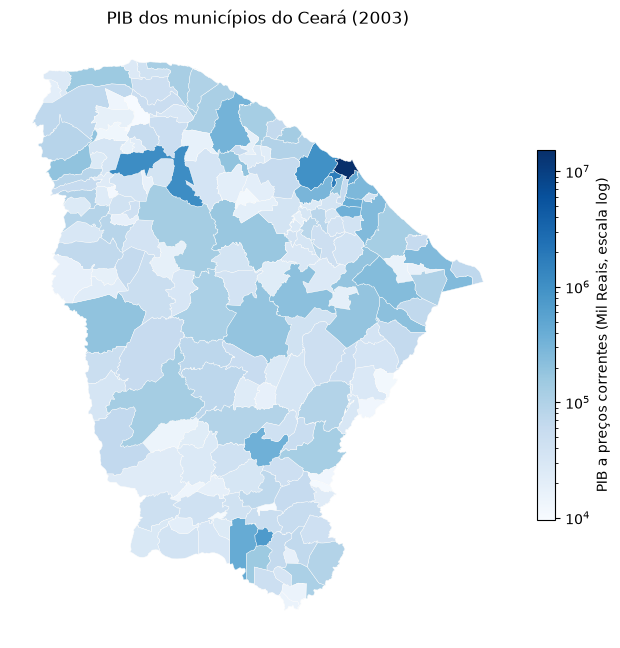

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_pib.plot(
    column=2003,
    cmap="Blues",
    norm=LogNorm(vmin=gdf_pib[2003].min(), vmax=gdf_pib[2003].max()),
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "PIB a preços correntes (Mil Reais, escala log)", "shrink": 0.6},
    ax=ax,
)

ax.set_title("PIB dos municípios do Ceará (2003)")
ax.axis("off")
plt.show()

Quais municípios mais cresceram em PIB (2003 -> 2023), no mapa?

Ranking de crescimento do PIB por município (2003 -> 2023):
  1. São Gonçalo do Amarante - CE     70.0x
  2. Itaitinga - CE                   38.4x
  3. Jijoca de Jericoacoara - CE      26.6x
  4. Pereiro - CE                     21.8x
  5. Aquiraz - CE                     17.8x
  6. Frecheirinha - CE                16.2x
  7. Uruoca - CE                      14.0x
  8. Cruz - CE                        13.9x
  9. Quixeré - CE                     11.8x
 10. Beberibe - CE                    11.5x
 11. Tianguá - CE                     11.5x
 12. Brejo Santo - CE                 11.1x
 13. Varjota - CE                     10.9x
 14. Eusébio - CE                     10.8x
 15. Barbalha - CE                    10.7x
 16. Solonópole - CE                  10.6x
 17. Quixeramobim - CE                10.4x
 18. Morada Nova - CE                 10.2x
 19. Caucaia - CE                     10.1x
 20. Acaraú - CE                      10.1x
 21. Ubajara - CE                     10.0x
 22. Penaforte -

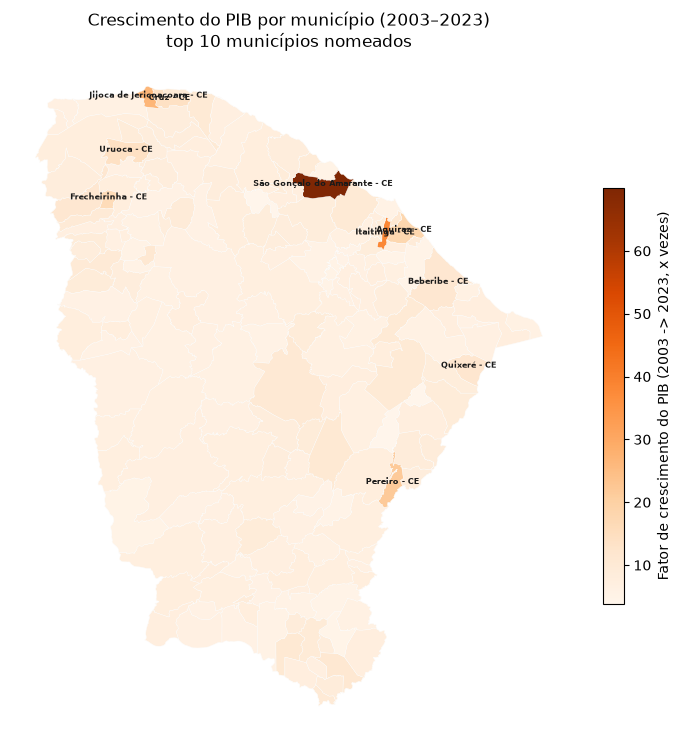

In [ ]:
gdf_pib["crescimento"] = gdf_pib[2023] / gdf_pib[2003]

ranking = gdf_pib[["nome", "crescimento"]].sort_values("crescimento", ascending=False).reset_index(drop=True)
ranking.index += 1

print("Ranking de crescimento do PIB por município (2003 -> 2023):")
for pos, row in ranking.iterrows():
    print(f"{pos:>3}. {row['nome']:<30} {row['crescimento']:>6.1f}x")

top10 = gdf_pib.nlargest(10, "crescimento")

fig, ax = plt.subplots(figsize=(9, 9))
gdf_pib.plot(
    column="crescimento",
    cmap="Oranges",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Fator de crescimento do PIB (2003 -> 2023, x vezes)", "shrink": 0.6},
    ax=ax,
)

for _, row in top10.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["nome"],
        xy=(centroide.x, centroide.y),
        fontsize=6,
        ha="center",
        color="#1a1a1a",
        weight="bold",
    )

ax.set_title("Crescimento do PIB por município (2003–2023)\ntop 10 municípios nomeados")
ax.axis("off")
plt.show()

Quais municípios são mais dependentes da agropecuária, no mapa?

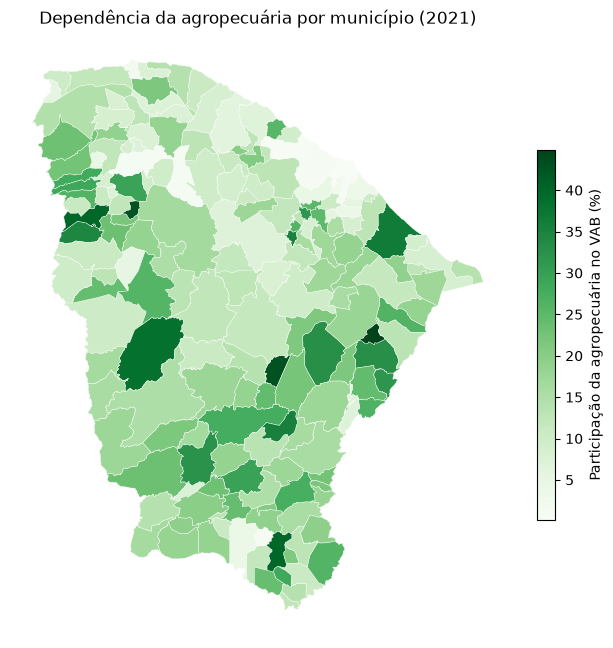

In [ ]:
pct_agro_geo = df_pib_raw[
    (df_pib_raw["nivel_territorial_nome"] == "Município")
    & (df_pib_raw["variavel_nome"] == "Participação do valor adicionado bruto a preços correntes da agropecuária no valor adicionado bruto a preços correntes total")
].copy()
pct_agro_geo["territorio_codigo"] = pct_agro_geo["territorio_codigo"].astype(str)
pct_agro_geo_pivot = pct_agro_geo.pivot(index="ano_nome", columns="territorio_codigo", values="valor")

ano_pct_geo = pct_agro_geo_pivot.dropna(how="all").index.max()

gdf_pct_agro = gdf_municipios.merge(
    pct_agro_geo_pivot.loc[ano_pct_geo].rename("participacao_agro"),
    left_on="codarea",
    right_index=True,
    how="left",
)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_pct_agro.plot(
    column="participacao_agro",
    cmap="Greens",
    edgecolor="#fcfcfb",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Participação da agropecuária no VAB (%)", "shrink": 0.6},
    ax=ax,
)

ax.set_title(f"Dependência da agropecuária por município ({ano_pct_geo})")
ax.axis("off")
plt.show()